<a href="https://colab.research.google.com/github/boanergescg/IA/blob/main/BOANERGES_CIPRIANO_GOMES_JUNIOR_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Vamos reproduzir os gráficos e algumas das possibilidades demonstradas no site:

https://playground.tensorflow.org/

Referências que podem ser úteis:

https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html
https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html
https://pytorch.org/tutorials/beginner/nn_tutorial.html

In [ ]:
from torch import linspace, sin, cos, ones_like, stack, rand, randn, tensor, cat, ones, zeros, sign, randperm, normal, uniform
from torch.nn.functional import relu, tanh, sigmoid, binary_cross_entropy_with_logits
import math
from matplotlib import pyplot as plt

N = 400               # numero total de amostras do dataset
NOISE = 25.           # intensidade do ruido de coleta no dataset
SPLIT_RATIO = 0.5     # porcentagem de dados usados no dataset de treino
BATCH_SIZE = 10       # tamanho do batch usado durante o treinamento
LEARNING_RATE = 0.03  # taxa de aprendizado

ImportError: cannot import name 'uniform' from 'torch' (/usr/local/lib/python3.11/dist-packages/torch/__init__.py)

In [2]:
import os
os.listdir('/')


['sys',
 'run',
 'lib32',
 'dev',
 'root',
 'tmp',
 'media',
 'proc',
 'usr',
 'srv',
 'lib',
 'mnt',
 'home',
 'boot',
 'libx32',
 'opt',
 'etc',
 'bin',
 'sbin',
 'var',
 'lib64',
 'kaggle',
 '.dockerenv',
 'datalab',
 'tools',
 'content',
 'python-apt',
 'python-apt.tar.xz',
 'NGC-DL-CONTAINER-LICENSE',
 'cuda-keyring_1.1-1_all.deb']

In [ ]:
def genSpiral(delta_t, label):
    r = 5*linspace(0., 1., N//2+1)[:N//2]
    t = 0.7*r*math.pi + delta_t
    x0 = r*sin(t)
    x1 = r*cos(t)
    y = label*ones_like(x0)
    x = stack((x0, x1), -1)
    sampled_noise = (NOISE/70.)*(2*rand(N//2, 2) - 1.)
    x += sampled_noise
    return x, y

class SpiralDataset:
    def __init__(self):
        xp, yp = genSpiral(0, 1) # positive samples
        xn, yn = genSpiral(math.pi, -1) # negative samples
        self.X = cat((xp, xn))
        self.Y = cat((yp, yn))

# TODO: gerar e plotar dataset

In [ ]:
def genGauss(cx0, cx1, label):
    x = 0.7*randn(N//2, 2)
    x = tensor([cx0, cx1]) + x + x*(NOISE/25.)
    y = label*ones(N//2)
    return x, y

class GaussDataset:
    def __init__(self):
        xp, yp = genGauss(2, 2, 1) # positive samples
        xn, yn = genGauss(-2, -2, -1) # negative samples
        self.X = cat((xp, xn))
        self.Y = cat((yp, yn))

# TODO: gerar e plotar dataset

In [ ]:
def genCircle(r_min, r_max, label):
    r = (r_max - r_min)*rand(N//2) + r_min
    angle = 2*math.pi*rand(N//2)
    x0 = r*sin(angle)
    x1 = r*cos(angle)
    x = stack((x0, x1), -1)
    sampled_noise = (NOISE/35.)*(2*rand(N//2, 2) - 1.)
    x += sampled_noise
    y = label*ones_like(x0)
    return x, y

class CircleDataset:
    def __init__(self):
        xp, yp = genCircle(0, 2.5, 1) # positive samples
        xn, yn = genCircle(3.5, 5, -1) # negative samples
        self.X = cat((xp, xn))
        self.Y = cat((yp, yn))

# TODO: gerar e plotar dataset

In [ ]:
def genXOR():
    x = 10.*rand(N, 2) - 5.
    y = sign(x[:,0]*x[:,1])
    padding = 0.3
    x += sign(x)*padding
    sampled_noise = (NOISE/25.)*(2*rand(N, 2) - 1.)
    x += sampled_noise
    return x, y

class XORDataset:
    def __init__(self):
        self.X, self.Y = genXOR()

# TODO: gerar e plotar dataset

In [ ]:
# TODO: implementar função "train_test_split", que tem como input um dos
# datasets gerados com as funções acima e gera 2 partições aleatórias desse
# dataset seguindo a proporção fixada pela constante SPLIT_RATIO.
def train_test_split(dataset):
    ...

In [ ]:
# TODO: implementar a classe "Model", que recebe como input uma lista de
# inteiros indicando o número de unidades em cada camada interna de uma rede
# neural totalmente conectada (uma MLP).
# Ex:
#    hidden_layers = [] -> model = regressão logística;
#    hidden_layers = [4, 2] -> model = MLP com 2 camadas internas, a primeira com 4 unidades e a segunda com 2 unidades.

class Model:
    def __init__(self, hidden_layers):
        ...

    def inference(self, inp):
        ...

    def update(self):
        ...

In [ ]:
# TODO: implementar função que realiza o loop de otimização com gradiente
# descendente estocástico (SGD) utilizando datasets e modelos gerados pelas
# funções e classes anteriores. Use também os hiperparâmetros fixados pelas
# constantes BATCH_SIZE e LEARNING_RATE
def train_loop(...):
    ...

# TODO: plotar as curvas de loss nos datasets de treino e test durante o treinamento

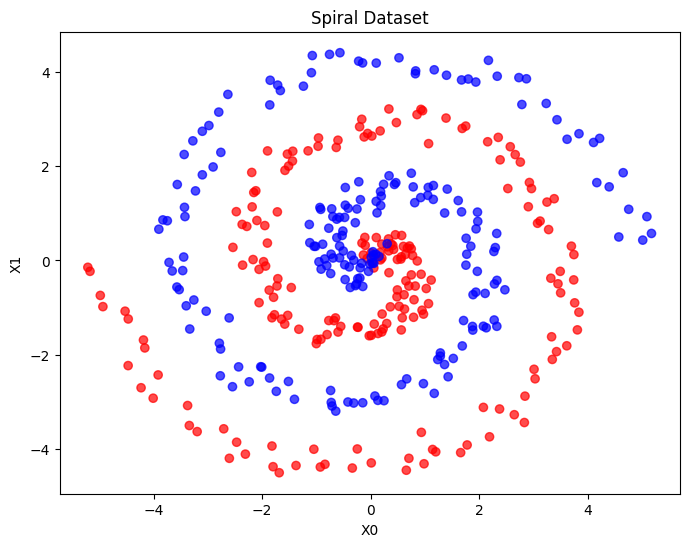

Spiral Dataset:
Tamanho do conjunto de treino: 200
Tamanho do conjunto de teste: 200


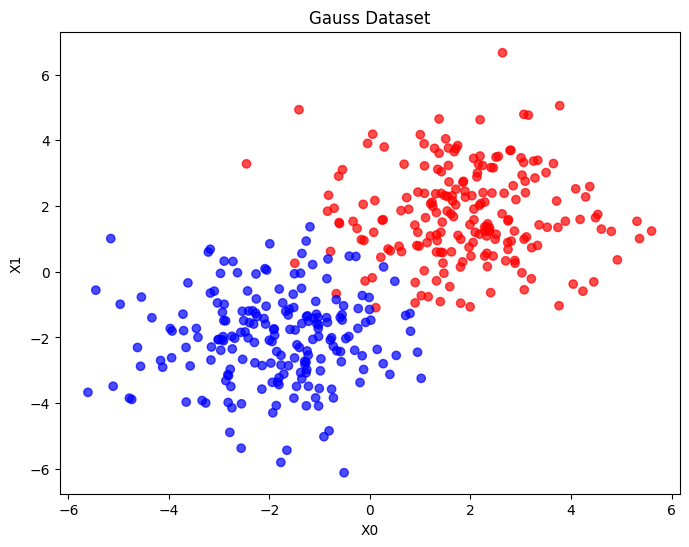

Gauss Dataset:
Tamanho do conjunto de treino: 200
Tamanho do conjunto de teste: 200


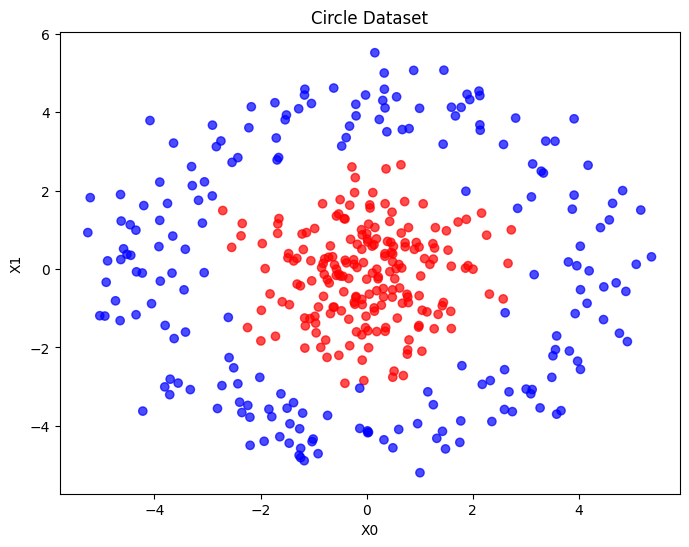

Circle Dataset:
Tamanho do conjunto de treino: 200
Tamanho do conjunto de teste: 200


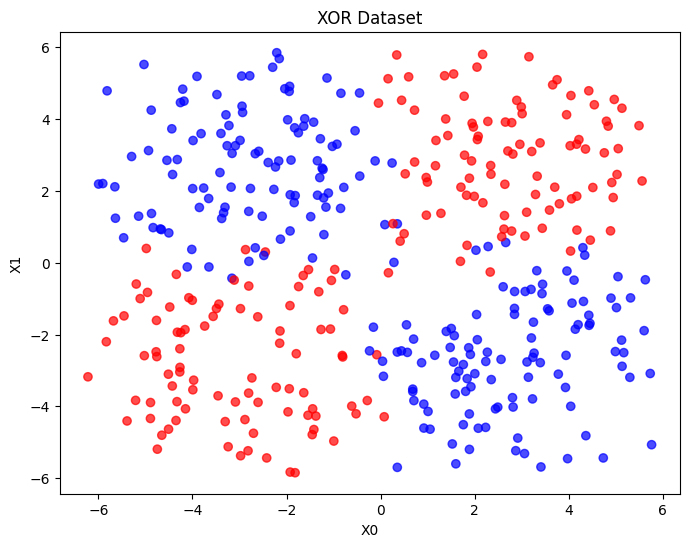

XOR Dataset:
Tamanho do conjunto de treino: 200
Tamanho do conjunto de teste: 200
Escolha a função de ativação para o modelo:
1 - ReLU
2 - Sigmoid
3 - Tanh
Digite o número correspondente à sua escolha: 2
Função de ativação escolhida: sigmoid
Epoch 0/100, Train Loss: 0.6940453052520752, Test Loss: 0.7048879861831665
Epoch 10/100, Train Loss: 0.6927284002304077, Test Loss: 0.7017185688018799
Epoch 20/100, Train Loss: 0.6919931769371033, Test Loss: 0.6995854377746582
Epoch 30/100, Train Loss: 0.6915820837020874, Test Loss: 0.6981225609779358
Epoch 40/100, Train Loss: 0.6913514733314514, Test Loss: 0.697101891040802
Epoch 50/100, Train Loss: 0.6912210583686829, Test Loss: 0.696378767490387
Epoch 60/100, Train Loss: 0.6911462545394897, Test Loss: 0.6958590745925903
Epoch 70/100, Train Loss: 0.6911022663116455, Test Loss: 0.6954811811447144
Epoch 80/100, Train Loss: 0.6910753846168518, Test Loss: 0.6952030658721924
Epoch 90/100, Train Loss: 0.6910579204559326, Test Loss: 0.6949965953826904


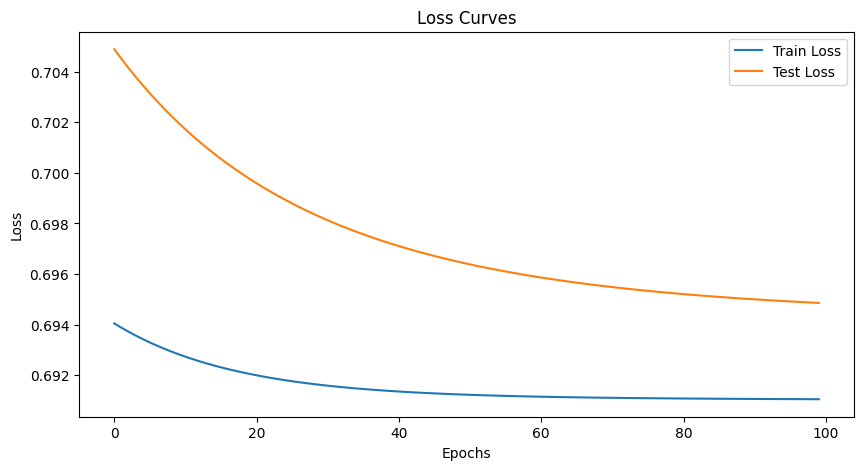

Epoch 0/100, Train Loss: 0.704924464225769, Test Loss: 0.7003321647644043
Epoch 10/100, Train Loss: 0.702105700969696, Test Loss: 0.699564516544342
Epoch 20/100, Train Loss: 0.7002261281013489, Test Loss: 0.6991877555847168
Epoch 30/100, Train Loss: 0.6988723278045654, Test Loss: 0.6989398002624512
Epoch 40/100, Train Loss: 0.6978152394294739, Test Loss: 0.6986997127532959
Epoch 50/100, Train Loss: 0.6969276666641235, Test Loss: 0.6984178423881531
Epoch 60/100, Train Loss: 0.6961387395858765, Test Loss: 0.6980797648429871
Epoch 70/100, Train Loss: 0.6954086422920227, Test Loss: 0.6976861357688904
Epoch 80/100, Train Loss: 0.6947143077850342, Test Loss: 0.6972444653511047
Epoch 90/100, Train Loss: 0.694042444229126, Test Loss: 0.6967629790306091


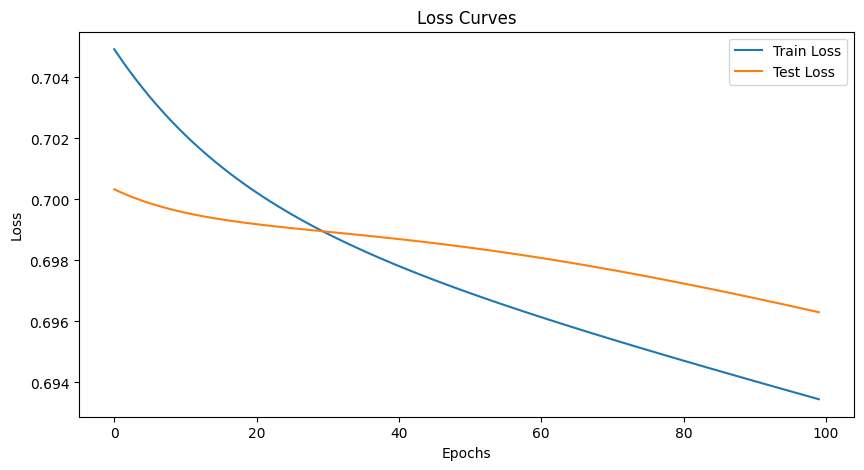

Epoch 0/100, Train Loss: 0.6904370188713074, Test Loss: 0.6983754634857178
Epoch 10/100, Train Loss: 0.6898022294044495, Test Loss: 0.700181245803833
Epoch 20/100, Train Loss: 0.6894478797912598, Test Loss: 0.7016369700431824
Epoch 30/100, Train Loss: 0.6892484426498413, Test Loss: 0.7027822732925415
Epoch 40/100, Train Loss: 0.6891348361968994, Test Loss: 0.7036693096160889
Epoch 50/100, Train Loss: 0.6890687346458435, Test Loss: 0.7043487429618835
Epoch 60/100, Train Loss: 0.6890289187431335, Test Loss: 0.7048653960227966
Epoch 70/100, Train Loss: 0.6890037059783936, Test Loss: 0.7052560448646545
Epoch 80/100, Train Loss: 0.6889865398406982, Test Loss: 0.7055503726005554
Epoch 90/100, Train Loss: 0.6889737844467163, Test Loss: 0.7057715654373169


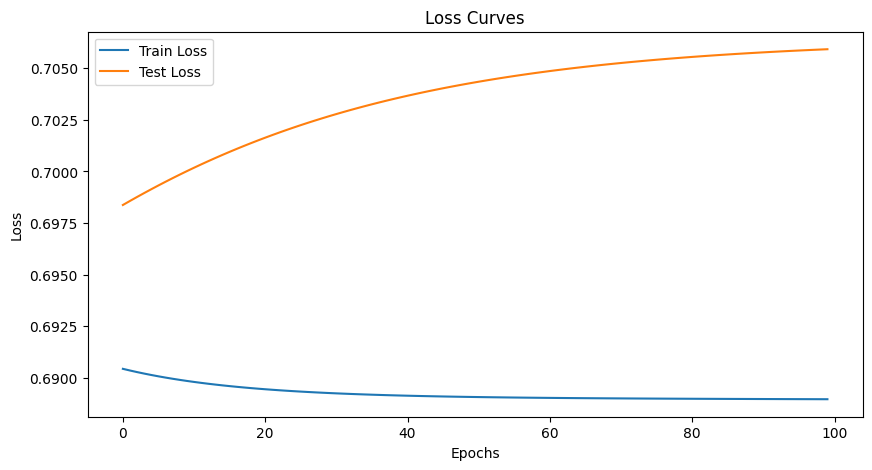

Epoch 0/100, Train Loss: 0.7010095119476318, Test Loss: 0.7124099135398865
Epoch 10/100, Train Loss: 0.6974263787269592, Test Loss: 0.7043346166610718
Epoch 20/100, Train Loss: 0.6954250931739807, Test Loss: 0.6989490985870361
Epoch 30/100, Train Loss: 0.6943047046661377, Test Loss: 0.6952875256538391
Epoch 40/100, Train Loss: 0.693673849105835, Test Loss: 0.6927528977394104
Epoch 50/100, Train Loss: 0.693314790725708, Test Loss: 0.6909703016281128
Epoch 60/100, Train Loss: 0.6931068301200867, Test Loss: 0.6896989345550537
Epoch 70/100, Train Loss: 0.6929827928543091, Test Loss: 0.6887816786766052
Epoch 80/100, Train Loss: 0.6929052472114563, Test Loss: 0.6881129741668701
Epoch 90/100, Train Loss: 0.6928538680076599, Test Loss: 0.6876213550567627


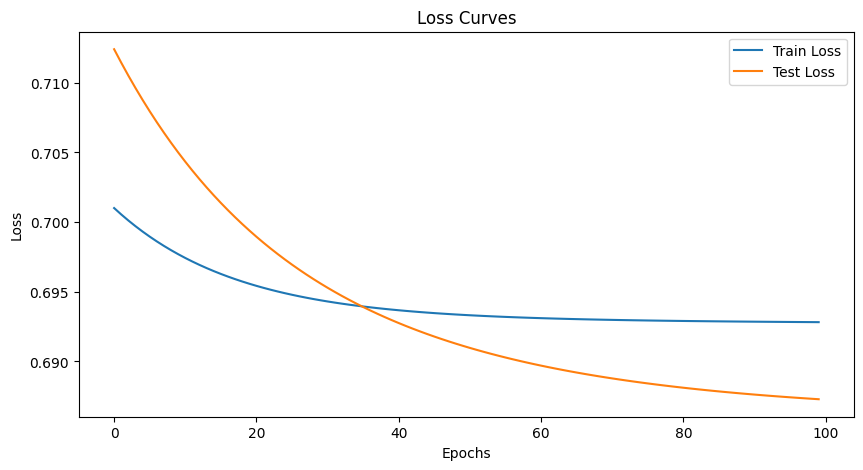

In [3]:
from torch import linspace, sin, cos, ones_like, stack, rand, randn, tensor, cat, ones, zeros, sign, randperm
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib import pyplot as plt
import math
import torch.nn.functional as F

# Constantes
N = 400  # Número total de amostras do dataset
NOISE = 25.  # Intensidade do ruído de coleta no dataset
SPLIT_RATIO = 0.5  # Porcentagem de dados usados no dataset de treino
BATCH_SIZE = 10  # Tamanho do batch usado durante o treinamento
LEARNING_RATE = 0.03  # Taxa de aprendizado

def genSpiral(delta_t, label):
    r = 5 * linspace(0., 1., N // 2 + 1)[:N // 2]
    t = 0.7 * r * math.pi + delta_t
    x0 = r * sin(t)
    x1 = r * cos(t)
    y = label * ones_like(x0)
    x = stack((x0, x1), -1)
    sampled_noise = (NOISE / 70.) * (2 * rand(N // 2, 2) - 1.)
    x += sampled_noise
    return x, y

def genGauss(cx0, cx1, label):
    x = 0.7 * randn(N // 2, 2)
    x = tensor([cx0, cx1]) + x + x * (NOISE / 25.)
    y = label * ones(N // 2)
    return x, y

def genCircle(r_min, r_max, label):
    r = (r_max - r_min) * rand(N // 2) + r_min
    angle = 2 * math.pi * rand(N // 2)
    x0 = r * sin(angle)
    x1 = r * cos(angle)
    x = stack((x0, x1), -1)
    sampled_noise = (NOISE / 35.) * (2 * rand(N // 2, 2) - 1.)
    x += sampled_noise
    y = label * ones_like(x0)
    return x, y

def genXOR():
    x = 10. * rand(N, 2) - 5.
    y = sign(x[:, 0] * x[:, 1])
    padding = 0.3
    x += sign(x) * padding
    sampled_noise = (NOISE / 25.) * (2 * rand(N, 2) - 1.)
    x += sampled_noise
    return x, y

class SpiralDataset:
    def __init__(self):
        xp, yp = genSpiral(0, 1)  # Positive samples
        xn, yn = genSpiral(math.pi, -1)  # Negative samples
        self.X = cat((xp, xn))
        self.Y = cat((yp, yn))

class GaussDataset:
    def __init__(self):
        xp, yp = genGauss(2, 2, 1)  # Positive samples
        xn, yn = genGauss(-2, -2, -1)  # Negative samples
        self.X = cat((xp, xn))
        self.Y = cat((yp, yn))

class CircleDataset:
    def __init__(self):
        xp, yp = genCircle(0, 2.5, 1)  # Positive samples
        xn, yn = genCircle(3.5, 5, -1)  # Negative samples
        self.X = cat((xp, xn))
        self.Y = cat((yp, yn))

class XORDataset:
    def __init__(self):
        self.X, self.Y = genXOR()

def plot_dataset(X, Y, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='bwr', alpha=0.7)
    plt.title(title)
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.savefig(f"{title.replace(' ', '_')}.png")  # Salva o gráfico como arquivo PNG
    plt.show()  # Exibe o gráfico
    plt.close()  # Fecha a figura para evitar consumo excessivo de memória

def train_test_split(dataset):
    total_samples = dataset.X.size(0)
    train_size = int(total_samples * SPLIT_RATIO)
    indices = randperm(total_samples)
    train_indices = indices[:train_size]
    test_indices = indices[train_size:]
    X_train, Y_train = dataset.X[train_indices], dataset.Y[train_indices]
    X_test, Y_test = dataset.X[test_indices], dataset.Y[test_indices]
    return (X_train, Y_train), (X_test, Y_test)

class Model(nn.Module):
    def __init__(self, hidden_layers, activation_function='relu'):
        super(Model, self).__init__()
        layers = []
        input_size = 2  # Tamanho da entrada (2 dimensões)

        # Dicionário para mapear funções de ativação
        activation_functions = {
            'relu': nn.ReLU(),
            'sigmoid': nn.Sigmoid(),
            'tanh': nn.Tanh()
        }

        # Verifica se a função de ativação fornecida é válida
        if activation_function not in activation_functions:
            raise ValueError(f"Função de ativação inválida: {activation_function}. Escolha entre {list(activation_functions.keys())}")

        for units in hidden_layers:
            layers.append(nn.Linear(input_size, units))
            layers.append(activation_functions[activation_function])  # Adiciona a função de ativação escolhida
            input_size = units

        layers.append(nn.Linear(input_size, 1))  # Camada de saída
        self.model = nn.Sequential(*layers)

    def inference(self, inp):
        return self.model(inp)  # Retorna logits diretamente

def train_loop(model, train_data, test_data, filename, epochs=100):
    X_train, Y_train = train_data
    X_test, Y_test = test_data
    train_losses = []
    test_losses = []
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model.inference(X_train)
        train_loss = F.binary_cross_entropy_with_logits(outputs.squeeze(), Y_train.float())
        train_loss.backward()
        optimizer.step()
        train_losses.append(train_loss.item())
        model.eval()
        with torch.no_grad():
            test_outputs = model.inference(X_test)
            test_loss = F.binary_cross_entropy_with_logits(test_outputs.squeeze(), Y_test.float())
            test_losses.append(test_loss.item())
        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs}, Train Loss: {train_loss.item()}, Test Loss: {test_loss.item()}")
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curves')
    plt.legend()
    plt.savefig(filename)
    plt.show() # exibir imagem
    plt.close()

# Visualizar SpiralDataset
spiral_dataset = SpiralDataset()
plot_dataset(spiral_dataset.X, spiral_dataset.Y, 'Spiral Dataset')

# Dividir o SpiralDataset em treino e teste
(train_X, train_Y), (test_X, test_Y) = train_test_split(spiral_dataset)
print("Spiral Dataset:")
print(f"Tamanho do conjunto de treino: {train_X.size(0)}")
print(f"Tamanho do conjunto de teste: {test_X.size(0)}")

# Visualizar GaussDataset
gauss_dataset = GaussDataset()
plot_dataset(gauss_dataset.X, gauss_dataset.Y, 'Gauss Dataset')

# Dividir o GaussDataset em treino e teste
(train_X, train_Y), (test_X, test_Y) = train_test_split(gauss_dataset)
print("Gauss Dataset:")
print(f"Tamanho do conjunto de treino: {train_X.size(0)}")
print(f"Tamanho do conjunto de teste: {test_X.size(0)}")

# Visualizar CircleDataset
circle_dataset = CircleDataset()
plot_dataset(circle_dataset.X, circle_dataset.Y, 'Circle Dataset')

# Dividir o CircleDataset em treino e teste
(train_X, train_Y), (test_X, test_Y) = train_test_split(circle_dataset)
print("Circle Dataset:")
print(f"Tamanho do conjunto de treino: {train_X.size(0)}")
print(f"Tamanho do conjunto de teste: {test_X.size(0)}")

# Visualizar XORDataset
xor_dataset = XORDataset()
plot_dataset(xor_dataset.X, xor_dataset.Y, 'XOR Dataset')

# Dividir o XORDataset em treino e teste
(train_X, train_Y), (test_X, test_Y) = train_test_split(xor_dataset)
print("XOR Dataset:")
print(f"Tamanho do conjunto de treino: {train_X.size(0)}")
print(f"Tamanho do conjunto de teste: {test_X.size(0)}")

# Solicitar escolha da função de ativação no terminal
print("Escolha a função de ativação para o modelo:")
print("1 - ReLU")
print("2 - Sigmoid")
print("3 - Tanh")

# Entrada do usuário para escolher a função de ativação
choice = input("Digite o número correspondente à sua escolha: ").strip()

# Dicionário para mapear as opções
activation_function = {
    "1": "relu",
    "2": "sigmoid",
    "3": "tanh"
}.get(choice, "relu")  # Se a entrada for inválida, o padrão é 'relu'

# Imprimir a função de ativação escolhida
print(f"Função de ativação escolhida: {activation_function}")

# Definir o modelo com a função de ativação escolhida
model = Model(hidden_layers=[10, 10], activation_function=activation_function)

# Exemplo de uso para SpiralDataset
spiral_dataset = SpiralDataset()
(train_X_spiral, train_Y_spiral), (test_X_spiral, test_Y_spiral) = train_test_split(spiral_dataset)
train_Y_spiral = (train_Y_spiral + 1) / 2
test_Y_spiral = (test_Y_spiral + 1) / 2

# Treinamento do modelo com o dataset Spiral
train_loop(model, (train_X_spiral, train_Y_spiral), (test_X_spiral, test_Y_spiral), 'loss_curves_spiral.png')

# Exemplo de uso para GaussDataset
gauss_dataset = GaussDataset()
(train_X_gauss, train_Y_gauss), (test_X_gauss, test_Y_gauss) = train_test_split(gauss_dataset)
train_Y_gauss = (train_Y_gauss + 1) / 2
test_Y_gauss = (test_Y_gauss + 1) / 2
train_loop(model, (train_X_gauss, train_Y_gauss), (test_X_gauss, test_Y_gauss), 'loss_curves_gauss.png')

# Exemplo de uso para CircleDataset
circle_dataset = CircleDataset()
(train_X_circle, train_Y_circle), (test_X_circle, test_Y_circle) = train_test_split(circle_dataset)
train_Y_circle = (train_Y_circle + 1) / 2
test_Y_circle = (test_Y_circle + 1) / 2
train_loop(model, (train_X_circle, train_Y_circle), (test_X_circle, test_Y_circle), 'loss_curves_circle.png')

# Exemplo de uso para XORDataset
xor_dataset = XORDataset()
(train_X_xor, train_Y_xor), (test_X_xor, test_Y_xor) = train_test_split(xor_dataset)
train_Y_xor = (train_Y_xor + 1) / 2
test_Y_xor = (test_Y_xor + 1) / 2
train_loop(model, (train_X_xor, train_Y_xor), (test_X_xor, test_Y_xor), 'loss_curves_xor.png')